In [1]:
from google.colab import files
uploaded = files.upload()

Saving Outcomes-a.txt to Outcomes-a.txt


In [2]:
import pandas as pd

df = pd.read_csv("Outcomes-a.txt")
df.head()

,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0


In [3]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(4000, 6)
Index(['RecordID', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival',
       'In-hospital_death'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   RecordID           4000 non-null   int64
 1   SAPS-I             4000 non-null   int64
 2   SOFA               4000 non-null   int64
 3   Length_of_stay     4000 non-null   int64
 4   Survival           4000 non-null   int64
 5   In-hospital_death  4000 non-null   int64
dtypes: int64(6)
memory usage: 187.6 KB
None
            RecordID       SAPS-I         SOFA  Length_of_stay     Survival  \
count    4000.000000  4000.000000  4000.000000     4000.000000  4000.000000   
mean   137605.122000    14.203500     6.402500       13.441750   128.735500   
std      2923.608886     6.088584     4.201298       12.246371   363.714273   
min    132539.000000    -1.000000    

In [4]:
print(df["In-hospital_death"].value_counts())
print(df["In-hospital_death"].value_counts(normalize=True))

In-hospital_death
0    3446
1     554
Name: count, dtype: int64
In-hospital_death
0    0.8615
1    0.1385
Name: proportion, dtype: float64


In [5]:
X = df[["SAPS-I", "SOFA"]]
y = df["In-hospital_death"]

In [6]:
print(X.isnull().sum())

SAPS-I    0
SOFA      0
dtype: int64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [9]:
X_train_df = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_df = pd.DataFrame(X_test_imputed, columns=X.columns)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_df, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_df, y_train)

RandomForestClassifier(random_state=42)

In [12]:
y_pred_lr = lr.predict(X_test_df)
y_pred_rf = rf.predict(X_test_df)

y_prob_lr = lr.predict_proba(X_test_df)[:, 1]
y_prob_rf = rf.predict_proba(X_test_df)[:, 1]

In [13]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nRandom Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       689
           1       1.00      0.01      0.02       111

    accuracy                           0.86       800
   macro avg       0.93      0.50      0.47       800
weighted avg       0.88      0.86      0.80       800

ROC-AUC: 0.6689156500477256
Confusion Matrix:
 [[689   0]
 [110   1]]

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       689
           1       0.48      0.09      0.15       111

    accuracy                           0.86       800
   macro avg       0.67      0.54      0.54       800
weighted avg       0.82      0.86      0.82       800

ROC-AUC: 0.6265053151845604
Confusion Matrix:
 [[678  11]
 [101  10]]


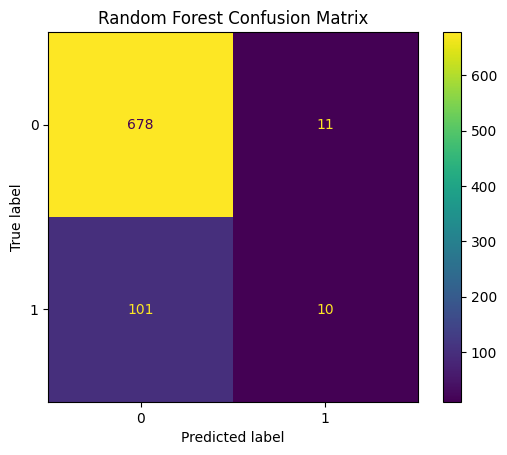

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test_df, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

                 Model   ROC_AUC
0  Logistic Regression  0.668916
1        Random Forest  0.626505


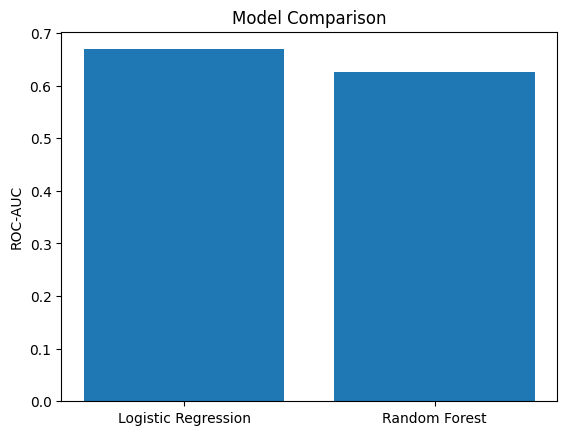

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results)

plt.bar(results["Model"], results["ROC_AUC"])
plt.ylabel("ROC-AUC")
plt.title("Model Comparison")
plt.show()

In [16]:
!pip install shap

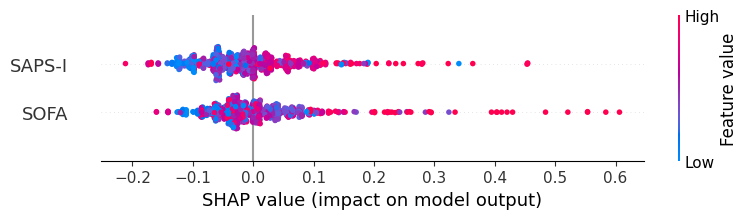

In [20]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make sure these are DataFrames with column names
X_train_df = pd.DataFrame(X_train_imputed, columns=X.columns)
X_test_df = pd.DataFrame(X_test_imputed, columns=X.columns)

# build explainer
explainer = shap.TreeExplainer(rf)

# compute shap values
shap_values = explainer.shap_values(X_test_df)

# handle binary classification output format
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

# summary plot
shap.summary_plot(shap_to_plot, X_test_df, feature_names=X_test_df.columns)
plt.show()

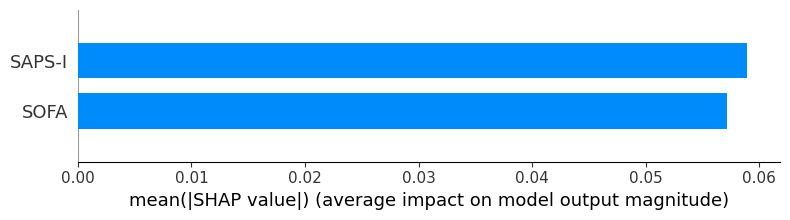

In [21]:
shap.summary_plot(shap_to_plot, X_test_df, feature_names=X_test_df.columns, plot_type="bar")
plt.show()

In [28]:
import numpy as np
import pandas as pd

mean_abs_shap = pd.DataFrame({
    "Feature": X_test_df.columns,
    "MeanAbsSHAP": np.abs(shap_to_plot).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

print(mean_abs_shap)

  Feature  MeanAbsSHAP
0  SAPS-I     0.058888
1    SOFA     0.057203


In [29]:
print("Top features driving ICU mortality prediction:")
print(mean_abs_shap.head(5))

Top features driving ICU mortality prediction:
  Feature  MeanAbsSHAP
0  SAPS-I     0.058888
1    SOFA     0.057203


In [30]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print("Cross-validated ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

Cross-validated ROC-AUC scores: [0.60716733 0.58306202 0.64898861 0.61802586 0.62009179]
Mean ROC-AUC: 0.6154671213834463


In [31]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       689
           1       0.48      0.09      0.15       111

    accuracy                           0.86       800
   macro avg       0.67      0.54      0.54       800
weighted avg       0.82      0.86      0.82       800



In [32]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_prob_rf))

0.6265053151845604
